<a href="https://colab.research.google.com/github/enriqueblancakhaldy/ebola-sir-montecarlo-simulation/blob/main/SIR_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Monte Carlo SIR Modeling of the 2014 Ebola Outbreak in Sierra Leone using Real Time Series Data.

It is very commont to use mathematical models to try to predict almost anything which happens in the world. This is the case of the SIR model, a compartimental static model that tries to predict how a disease would affect a certain population.

In this project we aim to evaluate the performance and accuracy of this model when applied to the 2014 Ebola outbreak in Sierra Leone. By fitting the simulation to real epidemiological time series data, we will assess how effectively the Monte Carlo approach captures the transmission dynamics, peak infection rate, and overall progression of the epidemic in a real-world scenario.
# The **SIR** epidemic model

This mathematical compartimental model consists in dividing a society into three compartments:


*   **S**: The number of susceptible individuals. These subset contains all those individuals that can get infected when they come in contact with someone that already has the disease

*   **I**: the number of infected individuals. In this compartment, we find everyone who has already fallen ill.

*  **R**: The recovered individuals. This subset consist of all those who got infected and after a specific amount of time lost the ability to infect other individuals. Is important to remark that this group contains all the dead individuals and thos ones who recovered from the infection.

As we are modeling how these three compartments of the general population change with time, we will consider these three numbers as functions of time $S(t), I(t), R(t)$ where $t\in \mathbb{R}$.

In this model, the birth rate is not taken into account, which lets as get our firs equation that links these three compartments:

\begin{equation}
S+I+R=N
\end{equation}

Where $N$ is the number of the total population.


Now that the bases is defined, we can describe the system of ordinary differential equations that lets us predict the behaviour of this three functions of time:



\begin{equation}
\left\{
\begin{aligned}
\frac{dS}{dt} &= -\frac{\beta}{N} I S, \\[1ex]
\frac{dI}{dt} &= \frac{\beta}{N} I S - \gamma I, \\[1ex]
\frac{dR}{dt} &= \gamma I,
\end{aligned}
\right.
\end{equation}

Where $\beta>0$ is the *infection rate* and $\gamma>0$ is the *recovery rate* as it can be deduced form the equations.

Another important number is the *basic reproduction number* $R_0:=\frac{\beta}{\gamma}$, which lets us know the infectiousness of the disease.






# Ebola time series

This project will use a data frame from *GitHub* containing data on Ebola cases from 2014 globally.
(https://github.com/cmrivers/ebola/blob/ddcbf44475a84b324ad8ca0c075784d070e70d37/country_timeseries.csv)

Firstly, we will need to *clean the data* to be able to work with it.

In [2]:
import pandas as pd

#We read the document from GitHub directly
df=pd.read_csv('https://raw.githubusercontent.com/cmrivers/ebola/ddcbf44475a84b324ad8ca0c075784d070e70d37/country_timeseries.csv')

#We adjust the date format and we sort the dates from past to future.
df['Date']=pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

#WE take the data from Sierra Leone and we interpolate linearly to aproximate the data we do not have
df['Cases_SierraLeone'] = df['Cases_SierraLeone'].interpolate(method='linear').fillna(0)
df['Deaths_SierraLeone'] = df['Deaths_SierraLeone'].interpolate(method='linear').fillna(0)

Now, we are able to visualize the data we got.

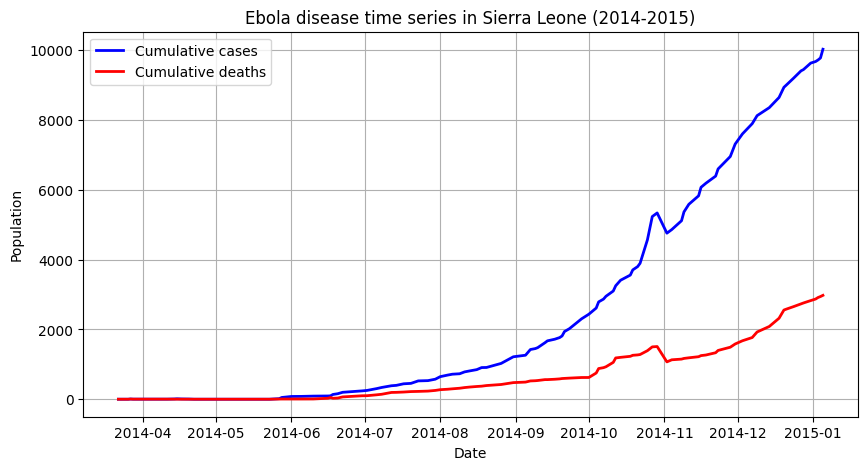

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Cases_SierraLeone'], label='Cumulative cases', color='blue', linewidth=2)
plt.plot(df['Date'], df['Deaths_SierraLeone'], label='Cumulative deaths', color='red', linewidth=2)

plt.title('Ebola disease time series in Sierra Leone (2014-2015)')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()

#Implementing the **SIR** model.

To implement the model in this specific case, we will use these numbers:

* $N=6,876,000$ (Population of Sierra Leone in 2014 according to [countryeconomy.com](https://https://countryeconomy.com/demography/population/sierra-leone?year=2014).

* According to the WHO Ebola Response Team (2014), the average infectious duration for the West African outbreak was estimated to be approximately $10$ days, which yields a recovery rate of $\gamma =\frac{1}{10\text{ day}}=0.1 \text{ day}^{-1}$. This is because  $\frac{dR}{dt}=\gamma I$, which means that each day  $\frac{1}{10}$  of the infected shall recover.


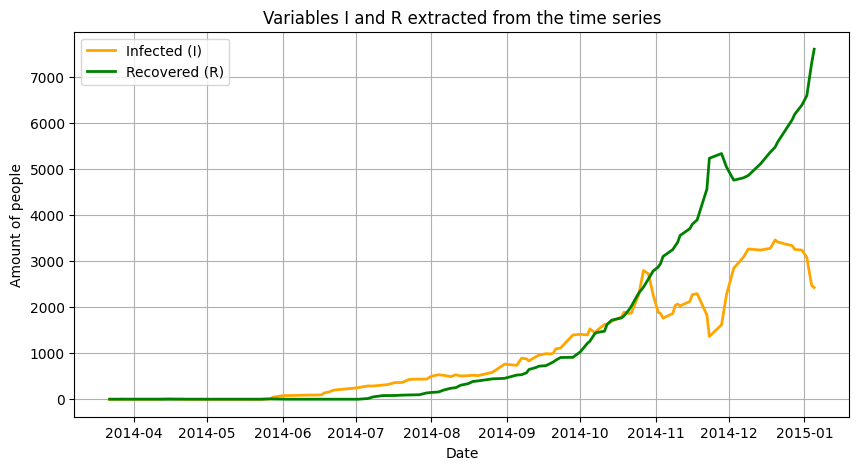

In [6]:
N= 6_876_000

#Active infectious individuals
df['I'] = df['Cases_SierraLeone'].diff(14)

# For the first 14 rows, we add the number of cases we already had documented
# using the command .fillna, as well as taking any negative value and replace it by 0.
df['I'] = df['I'].fillna(df['Cases_SierraLeone']).clip(lower=0)

# Recovered individuals
df['R']= df['Cases_SierraLeone']- df['I']

# Susceptible individuals
df['S']= N-df['I']- df['R']

#Now we visualize these data

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['I'], label='Infected (I)', color='orange', linewidth=2)
plt.plot(df['Date'], df['R'], label='Recovered (R)', color='green', linewidth=2)


plt.title('Variables I and R extracted from the time series')
plt.xlabel('Date')
plt.ylabel('Amount of people')
plt.legend()
plt.grid(True)
plt.show()

Once extracted the variables from the Time Series, we need to compute the approximated value of the infectious rate $\beta$ to run the model.
To do so, we will isolate $\beta$ in the equation

\begin{equation}
\frac{dI}{dt} = \frac{\beta}{N} I S - \gamma I,
\end{equation}

which leads us to

\begin{equation}
\beta = \frac{N}{IS}(\frac{dI}{dt}+ \gamma I).
\end{equation}

As we are solving this numerically and in this case time is discrete, we will take $\frac{dI}{dt}(t)\approx \Delta I(t)=I(t)-I(t-1)$.




In [21]:
import numpy as np

gamma= 1/10

#we use the equation to calculate beta, taking into account that may be cases in which we divide by 0
dI_dt= df['I'].diff(1).fillna(0)
beta_column= ((dI_dt+gamma*df['I'])/df['I']).replace([np.inf, -np.inf], np.nan)

# we calculate the average between the days 14 and 60 to avoid numerical noise.
beta = beta_column.iloc[14:60].median()

print(f"approximated Beta (β): {beta:.4f}")

approximated Beta (β): 0.1577


These computations yield a basic reproduction number of $R_0 = \frac{0.1577}{0.1} = 1.410$. Since $R_0 > 1$, this indicates that an infected individual will, on average, transmit the virus to more than one susceptible person, causing the outbreak to grow exponentially.

Now, we can finally run the model to see this and compare it to the real data.

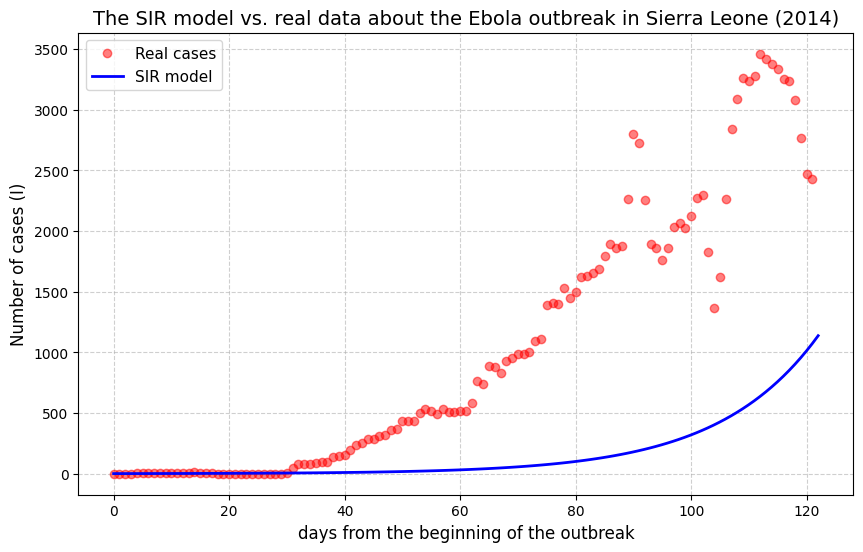

In [22]:
from scipy.integrate import odeint #we include this library to solve the differential equations


#We define the differential equations in a function
def sir(y, t, N, beta, gamma):

    S, I, R = y[0], y[1], y[2] # we define the solution as an array
    dSdt = -beta * S * I/N
    dIdt = beta * S * I/N - gamma * I
    dRdt = gamma * I
    return np.array([dSdt, dIdt, dRdt])

#Now we get all the initial values for a specific solution from the data frame
S0 = df['S'].iloc[0]
I0 = df['I'].iloc[0]
R0_comp = df['R'].iloc[0] #We name it this way to avoid confusion with the basic reproduction number

# If I0 is 0, the SIR model will not start. In this case, will set it 1 infected individual.
if I0 == 0.0:
    I0 = 1.0
    S0 = N - I0 - R0_comp # Adjust S0 if I0 changes

# we define t as a vector which lenght is the number of days of the data frame
t = np.linspace(0, len(df), len(df))

#we solve the differential equations numerically
sol = odeint(sir, np.array([S0, I0, R0_comp]), t, args=(N, beta, gamma))

#we transpose the vector of solutions tu assign the solutions correctly
S_sim, I_sim, R_sim = sol.T

#Now we can visualize how the number of infected individuals behave
plt.figure(figsize=(10, 6))

# These are the real cases we got from the dataframe
plt.plot(df.index, df['I'], 'ro', alpha=0.5, label='Real cases')

# These are the cases predicted by the SIR model
plt.plot(t, I_sim, 'b-', linewidth=2, label='SIR model')


plt.title('The SIR model vs. real data about the Ebola outbreak in Sierra Leone (2014)', fontsize=14)
plt.xlabel('days from the beginning of the outbreak', fontsize=12)
plt.ylabel('Infectious individuals (I)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

As it is shown, the predicts well the first 30 days, but after that the outbreak behaved differently from what the model predicted.

To make a better approximation with the model, we will use a method used by mathematicians almost in every area: The MonteCarlo method.

We will execute $500$ runs of the SIR model, treating the parameters $\beta$ and $\gamma$ as random variables drawn from normal distributions. To evaluate model fit against the empirical data, we are going to plot the median trajectory of these simulations alongside a $90\%$ confidence interval."



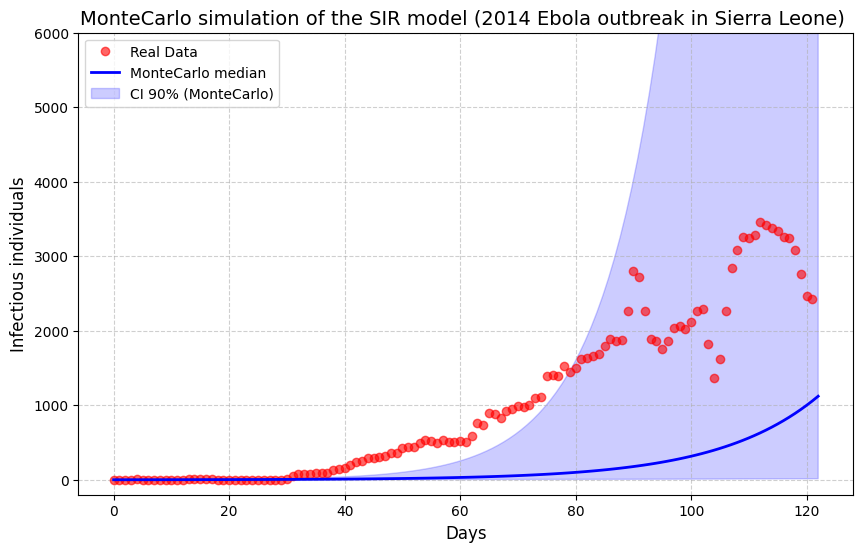

In [29]:
# We firstly define the number of simulations
sim_number=500

# We adjust the averages and standard deviations
beta_average, beta_std = 0.1577, 0.005
gamma_average, gamma_std = 0.1, 0.02

# We use a matrix to keep track of each simulation
# rows: days, Columns: each simulation
I_montecarlo = np.zeros((len(t), sim_number))


np.random.seed(42)  # we use this random see to be able to reproduce the experiment

for i in range(sim_number):
    # firstly we generate random numbers for beta and gamma
    beta_i = np.random.normal(beta_average, beta_std)
    gamma_i = np.random.normal(gamma_average, gamma_std)

    #We want these to be positive numbers
    beta_i = max(0, beta_i)
    gamma_i = max(0, gamma_i)

    # We now sove the system of differential equations for these parameters
    ret = odeint(sir, [S0, I0, R0_comp], t, args=(N, beta_i, gamma_i))
    S_sim, I_sim, R_sim = ret.T

    # We update a new matrix column with this simulation
    I_montecarlo[:, i] = I_sim


    # We compute the median and important percentiles (90% conficence interval)
I_median = np.median(I_montecarlo, axis=1)
I_low = np.percentile(I_montecarlo, 5, axis=1)   # Percentile 5
I_high = np.percentile(I_montecarlo, 95, axis=1) # Percentile 95

# Finally, we visualize the data
plt.figure(figsize=(10, 6))

# Real data
plt.plot(df.index, df['I'], 'ro', alpha=0.6, label='Real Data')

# Median of the MonteCarlo Method
plt.plot(t, I_median, 'b-', linewidth=2, label='MonteCarlo median')
plt.fill_between(t, I_low, I_high, color='blue', alpha=0.2, label='CI 90% (MonteCarlo)')


plt.title('MonteCarlo simulation of the SIR model (2014 Ebola outbreak in Sierra Leone) ', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Infectious individuals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-200, 6000)
plt.legend()
plt.show()

#Conclussions

From just observing the graphic, we can understand that the prediction of the SIR model was not very accurate. We can rigorously affirm this using mathematical criteria as the **RMSE**(Root Mean Squared Error) or the **Interval Coverage**:

In [35]:
# 1. We create a "boolean mask" which yields true if the ral point is inside the CI.
inside_CI = (df['I'] >= I_low) & (df['I'] <= I_high)

# 2. We compute the percentage of data that ara inside teh CI
interval_coverage = np.mean(inside_CI) * 100

print(f"Interval Coverage: {interval_coverage:.2f}%")

Interval Coverage: 40.98%


In [36]:
from sklearn.metrics import root_mean_squared_error

# we compute the RMSE directly with this library
rmse = root_mean_squared_error(df['I'], I_median)
print(f"RMSE: {rmse:.2f}")

RMSE: 1245.14




*   **Interval Coverage**: $40.98\%$. This means that $40.98\%$ of the real data are inside the range the $90\%$ confidence interval of the MonteCarlo simulations provides us, falling well short of the theoretical $90\%$ target.

*    **RMSE**: $1,245.14$ active cases. This reflects the average magnitude of the model's prediction error. Given that peak active cases reached approximately $3,500$, an RMSE of this magnitude quantitatively highlights the model's limitations in tracking the late-stage epidemic dynamics.

#Why did we get this outcome?

As expected, the standard SIR model presents clear limitations due to its reliance on a small set of constant parameters. As shown in the results, the simulation accurately captures the beginning of the outbreak; however, around day $30$, it begins to diverge from the empirical data observed in Sierra Leone.This divergence occurs because the basic model fails to account for critical real-world factors, such as public health interventions, hospitalizations, changes in population behavior over time, immunity, the birth rate, etc. Furthermore, this discrepancy is amplified by the heteroscedasticity inherent in the outbreak dynamics, as the uncertainty within the MonteCarlo simulations expands significantly over time rather than remaining constant.






# How can we improve the prediction ?

While the standard SIR framework provides a foundational baseline, real-world epidemic dynamics often require more nuanced compartmental structures. For instance, incorporating an Exposed ($E$) state via a SEIR model would account for the latent incubation period characteristic of Ebola. Similarly, advanced frameworks like MSIR incorporate passive maternal immunity, while other custom extensions integrate vaccination compartments, diagnostic detection states, or vector-borne transmission mechanics (e.g., fleas, ticks, or mosquitoes). Implementing a time-varying transmission rate $\beta(t)$ or expanding to a SEIR framework represents a logical next step to better capture Sierra Leone's full outbreak trajectory.

Beyond structural changes like the SEIR model, replacing the deterministic framework with a Bayesian SIR model represents another powerful extension. By using probabilistic programming tools (such as PyMC or Stan) alongside Markov Chain Monte Carlo (MCMC) sampling, we can treat parameters like $\beta$ and $\gamma$ as dynamic probability distributions rather than fixed constants. This Bayesian approach automatically updates parameter estimates as new data arrives, naturally capturing time-varying dynamics and providing a mathematically rigorous quantification of uncertainty.

